# Étape 3 — Comparaison de modèles

Les entraînements tournent via `src/run_step3_models.py` (long sur ce volume, donc hors notebook). Ici je récupère les runs depuis MLFlow et je compare LightGBM (GBDT et GOSS) + XGBoost aux baselines LR/RF de l'Étape 2.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import mlflow
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import training

training.setup_mlflow()
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)

## Récupération des runs

In [2]:
exp = mlflow.get_experiment_by_name(training.EXPERIMENT_NAME)
runs = mlflow.search_runs(experiment_ids=[exp.experiment_id], order_by=["start_time ASC"])

cols_keep = {
    "tags.mlflow.runName": "run",
    "params.model": "model",
    "tags.step": "step",
    "metrics.auc_mean": "auc_mean",
    "metrics.auc_std": "auc_std",
    "metrics.recall_minority_mean": "recall",
    "metrics.f1_mean": "f1",
    "metrics.business_cost_mean": "cost",
}
have = [c for c in cols_keep if c in runs.columns]
summary = runs[have].rename(columns=cols_keep).dropna(subset=["auc_mean"])
summary

,run,model,step,auc_mean,auc_std,recall,f1,cost
0,logreg_baseline,LogisticRegression,2,0.772122,0.001915,0.700665,0.279410,52198.0
1,rf_baseline,RandomForest,2,0.740144,0.001633,0.526848,0.278075,57876.0
2,lgbm_gbdt,LightGBM,3,0.790939,0.004202,0.057080,0.103870,47023.6
3,lgbm_goss,LightGBM,3,0.792329,0.004069,0.054783,0.099989,47133.0
4,xgboost,XGBoost,3,0.792015,0.003602,0.054300,0.099070,47161.6


## Classement

Trié par coût métier (FN coûte 10× plus qu'un FP). Au seuil 0.5 par défaut — la vraie optimisation de seuil arrive en Étape 4.

In [3]:
ranking = summary.sort_values("cost").reset_index(drop=True)
ranking[["run", "model", "auc_mean", "recall", "f1", "cost"]].round(4)

,run,model,auc_mean,recall,f1,cost
0,lgbm_gbdt,LightGBM,0.7909,0.0571,0.1039,47023.6
1,lgbm_goss,LightGBM,0.7923,0.0548,0.1000,47133.0
2,xgboost,XGBoost,0.7920,0.0543,0.0991,47161.6
3,logreg_baseline,LogisticRegression,0.7721,0.7007,0.2794,52198.0
4,rf_baseline,RandomForest,0.7401,0.5268,0.2781,57876.0


## Visualisations

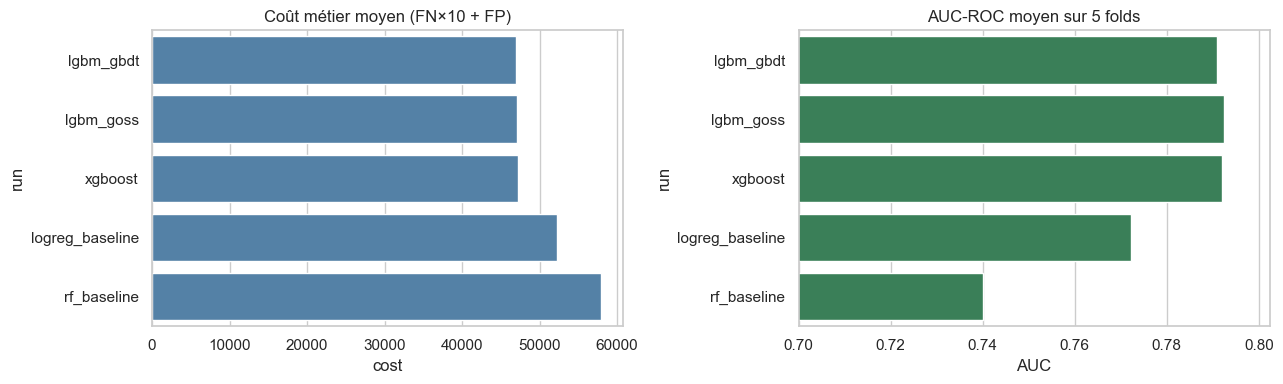

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

order = ranking["run"].tolist()
sns.barplot(data=ranking, x="cost", y="run", order=order, ax=axes[0], color="steelblue")
axes[0].set_title("Coût métier moyen (FN×10 + FP)")
axes[0].set_xlabel("cost")

sns.barplot(data=ranking, x="auc_mean", y="run", order=order, ax=axes[1], color="seagreen")
axes[1].set_xlim(0.7, ranking["auc_mean"].max() + 0.01)
axes[1].set_title("AUC-ROC moyen sur 5 folds")
axes[1].set_xlabel("AUC")

plt.tight_layout(); plt.show()

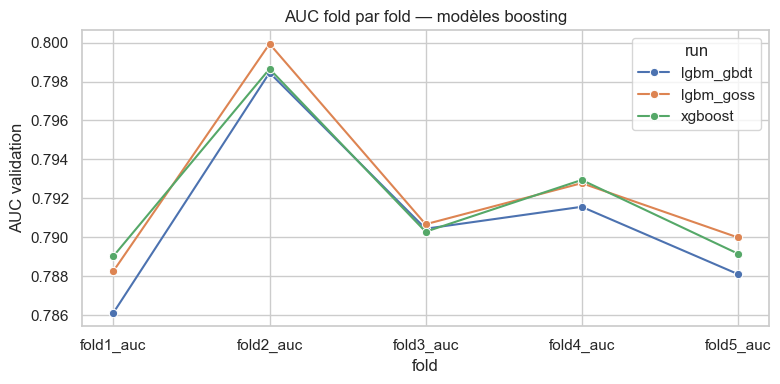

In [5]:
# AUC par fold pour les modèles Step 3 (boosting). Permet de voir la stabilité.
fold_cols = [f"metrics.fold{i}_auc" for i in range(1, 6)]
have_fold = [c for c in fold_cols if c in runs.columns]
step3 = runs[runs.get("tags.step") == "3"][["tags.mlflow.runName"] + have_fold].dropna()
step3.columns = ["run"] + [c.split(".")[-1] for c in have_fold]
step3_long = step3.melt(id_vars="run", var_name="fold", value_name="auc")

fig, ax = plt.subplots(figsize=(8, 4))
sns.lineplot(data=step3_long, x="fold", y="auc", hue="run", marker="o", ax=ax)
ax.set_title("AUC fold par fold — modèles boosting")
ax.set_ylabel("AUC validation")
plt.tight_layout(); plt.show()

## Le modèle retenu pour la suite

On garde le run avec le coût métier le plus bas pour l'Étape 4 (optimisation du seuil + hyperparamètres). Si l'AUC est > 0.82, je creuse pour data leakage.

In [6]:
best = ranking.iloc[0]
print("Meilleur run :", best["run"])
print(f"  AUC moyen      : {best['auc_mean']:.4f}")
print(f"  Recall classe 1: {best['recall']:.3f}")
print(f"  Business cost  : {int(best['cost'])}")
if best["auc_mean"] > 0.82:
    print("\nATTENTION : AUC > 0.82, vérifier data leakage.")

Meilleur run : lgbm_gbdt
  AUC moyen      : 0.7909
  Recall classe 1: 0.057
  Business cost  : 47023
